In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

Часть 1

In [ ]:
def generate_random_vectors(M, B, N):
    A = np.zeros((2,2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[1, 0] / A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - (B[1, 0]**2 / B[0, 0]))

    E = np.random.randn(2, N)

    X = np.dot(A, E) + M
    return X

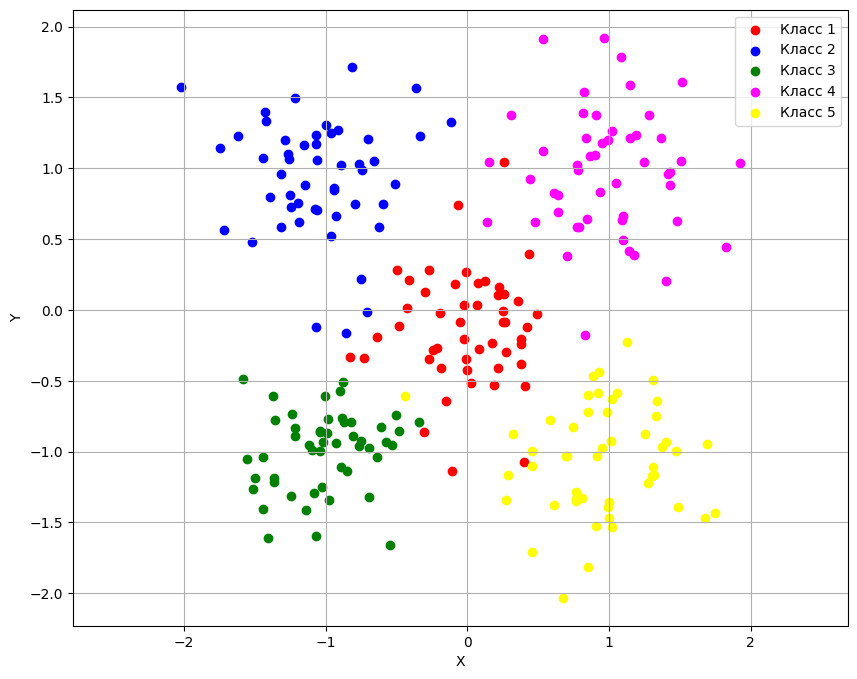

In [281]:
N = 50

M1 = np.array([[0], [0]])
M2 = np.array([[-1], [1]])
M3 = np.array([[-1], [-1]])
M4 = np.array([[1], [1]])
M5 = np.array([[1], [-1]])

# B1 = np.array([[0.08, 0.01], 
#                [0.01, 0.07]])
# B2 = np.array([[0.06, 0.00], 
#                [0.00, 0.07]])
# B3 = np.array([[0.07, 0.015], 
#                [0.015, 0.09]])
# B4 = np.array([[0.07, -0.01], 
#                [-0.01, 0.08]])
# B5 = np.array([[0.08, 0.00], 
#                [0.00, 0.07]])

B1 = np.array([[0.15, 0.0], 
               [0.0, 0.15]])
B2 = np.array([[0.1, -0.3], 
               [-0.3, 0.1]])
B3 = np.array([[0.1, 0.15], 
               [0.15, 0.1]])
B4 = np.array([[0.1, -0.01], 
               [-0.01, 0.1]])
B5 = np.array([[0.1, 0.4], 
               [0.4, 0.1]])


X1 = generate_random_vectors(M1, B1, N)
X2 = generate_random_vectors(M2, B1, N)
X3 = generate_random_vectors(M3, B1, N)
X4 = generate_random_vectors(M4, B1, N)
X5 = generate_random_vectors(M5, B1, N)

plt.figure(figsize=(10, 8))
plt.scatter(X1[0, :], X1[1, :], color='red', label='Класс 1')
plt.scatter(X2[0, :], X2[1, :], color='blue', label='Класс 2')
plt.scatter(X3[0, :], X3[1, :], color='green', label='Класс 3')
plt.scatter(X4[0, :], X4[1, :], color='magenta', label='Класс 4')
plt.scatter(X5[0, :], X5[1, :], color='yellow', label='Класс 5')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Часть 2

In [282]:
X4

array([[ 1.42895821,  0.70667632,  0.81828961,  1.47802212,  0.78813842,
         0.96180555,  0.84044476,  0.30936129,  0.95224315,  0.60858787,
         1.09859858,  1.42821195,  0.1424542 ,  0.84240173,  1.17518403,
         0.1543926 ,  1.51753335,  1.14713155,  1.41952652,  0.78158393,
         0.8283026 ,  0.93766962,  1.8281248 ,  1.51050001,  1.05125804,
         1.09852938,  1.24589719,  1.9262452 ,  1.14822674,  1.0178    ,
         0.8688614 ,  1.09098228,  0.77264743,  1.19213574,  0.44515771,
         0.89910856,  1.28452208,  1.14296098,  0.82082626,  0.91013729,
         1.4009834 ,  0.53121344,  0.53346289,  0.63995432,  0.99586448,
         0.47453761,  1.36909593,  0.64202307,  1.08689253,  0.77572595],
       [ 0.97463309,  0.3790268 ,  1.38780811,  0.62761343,  0.58705604,
         1.92138623,  1.2146823 ,  1.37274227,  1.17772787,  0.82475503,
         0.49385923,  0.88426736,  0.62116051,  0.64441552,  0.38683418,
         1.04433635,  1.6093799 ,  1.21616542,  0.

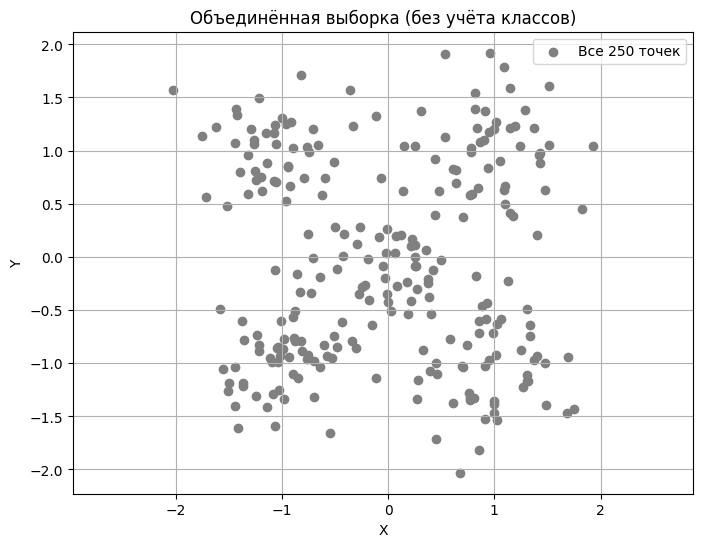

In [283]:
all_data = np.hstack([X1, X2, X3, X4, X5]).T

plt.figure(figsize=(8, 6))
plt.scatter(all_data[:, 0], all_data[:, 1], c='gray', label='Все 250 точек')
plt.title('Объединённая выборка (без учёта классов)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

Часть 3

In [284]:
def maximin_clustering(data):
    n_samples = data.shape[0]
    centers = []
    
    # Шаг 1
    mean_point = np.mean(data, axis=0)
    distances_to_mean = cdist(data, mean_point.reshape(1, -1)).flatten()
    first_center_idx = np.argmax(distances_to_mean)
    centers.append(data[first_center_idx])
    
    # Шаг 2
    distances_to_first = cdist(data, np.array([centers[0]])).flatten()
    second_center_idx = np.argmax(distances_to_first)
    centers.append(data[second_center_idx])
    
    # Шаг 3
    current_centers = np.array(centers)
    remaining_indices = np.setdiff1d(np.arange(n_samples), [first_center_idx, second_center_idx])
    
    while True:
        if len(remaining_indices) == 0:
            break
        distances_to_centers = cdist(data[remaining_indices], current_centers)
        min_distances = np.min(distances_to_centers, axis=1)
        candidate_idx_in_remaining = np.argmax(min_distances)
        candidate_idx = remaining_indices[candidate_idx_in_remaining]
        candidate_point = data[candidate_idx]
        candidate_min_distance = min_distances[candidate_idx_in_remaining]
        
        if len(current_centers) >= 2:
            center_distances = cdist(current_centers, current_centers)
            upper_tri = center_distances[np.triu_indices_from(center_distances, k=1)]
            avg_center_distance = np.mean(upper_tri)
            typical_distance = 0.5 * avg_center_distance
        else:
            typical_distance = np.inf
        if candidate_min_distance > typical_distance:
            centers.append(candidate_point)
            current_centers = np.array(centers)
            remaining_indices = np.delete(remaining_indices, candidate_idx_in_remaining)
        else:
            break
    
    centers = np.array(centers)
    
    distances_all = cdist(data, centers)
    labels = np.argmin(distances_all, axis=1)
    
    return centers, labels

centers, labels = maximin_clustering(all_data)

print(f"Найдено кластеров: {len(centers)}")
print("Центры кластеров:")
print(centers)

Найдено кластеров: 8
Центры кластеров:
[[-2.02382944  1.5700669 ]
 [ 1.7479161  -1.43248601]
 [-1.40996524 -1.60837288]
 [ 1.08689253  1.78248188]
 [-0.41260274  0.21070496]
 [ 1.4009834   0.20431872]
 [ 0.28543147 -1.1632626 ]
 [-0.36039623  1.56809865]]


C:\Users\User\AppData\Local\Temp\ipykernel_8864\2595261082.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


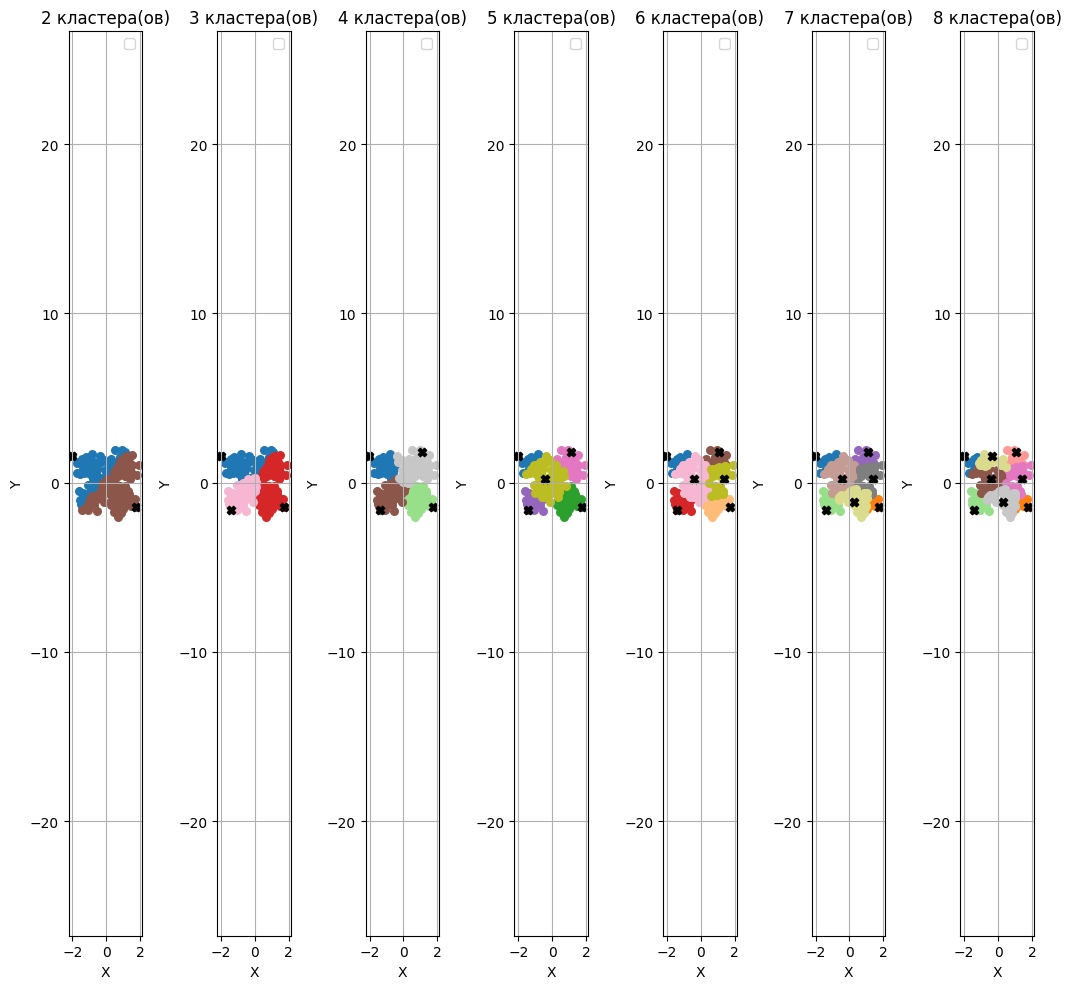

In [290]:
max_clusters_to_show = min(len(centers), np.inf)

fig, axes = plt.subplots(1, 10, figsize=(15, 10))
axes = axes.flatten()
cmap = plt.cm.tab20

for k in range(2, max_clusters_to_show + 1):
    if k <= len(centers):
        k_centers = centers[:k]
        distances = cdist(all_data, k_centers)
        k_labels = np.argmin(distances, axis=1)
    else:
        k_centers = centers
        k_labels = labels
    
    # colors = ['red', 'blue', 'green', 'magenta', 'yellow']
    colors = [cmap(i / max(k, 1)) for i in range(k)]
    ax = axes[k-2]
    for cluster_id in range(k):
        mask = (k_labels == cluster_id)
        ax.scatter(all_data[mask, 0], all_data[mask, 1], color=colors[cluster_id], s=30)
    ax.scatter(k_centers[:, 0], k_centers[:, 1], c='black', marker='X')
    ax.set_title(f'{k} кластера(ов)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    ax.grid(True)
    ax.axis('equal')

for i in range(k-1, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

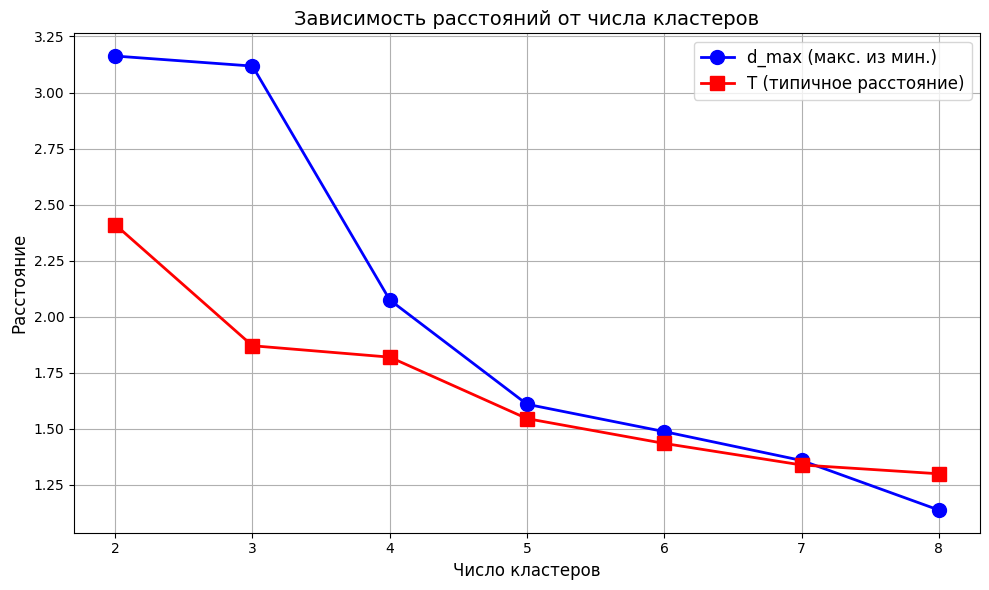

In [292]:
max_min_distances = []
typical_distances = []

for k in range(2, max_clusters_to_show + 1):
    k_centers = centers[:k]
    
    distances_to_centers = cdist(all_data, k_centers)
    min_distances = np.min(distances_to_centers, axis=1)
    d_max = np.max(min_distances)
    max_min_distances.append(d_max)
    
    if k >= 2:
        center_distances = cdist(k_centers, k_centers)
        upper_tri = center_distances[np.triu_indices_from(center_distances, k=1)]
        avg_center_distance = np.mean(upper_tri)
        T = 0.5 * avg_center_distance
    else:
        T = 0
    typical_distances.append(T)

plt.figure(figsize=(10, 6))
x_values = list(range(2, max_clusters_to_show + 1))
plt.plot(x_values, max_min_distances, 'bo-', linewidth=2, markersize=10, label='d_max (макс. из мин.)')
plt.plot(x_values, typical_distances, 'rs-', linewidth=2, markersize=10, label='T (типичное расстояние)')
plt.xlabel('Число кластеров', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)
plt.title('Зависимость расстояний от числа кластеров', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.xticks(x_values)
plt.tight_layout()
plt.show()

Часть 4

In [293]:
def k_means(data, k, initial_centers, max_iters=100):

    centers = initial_centers.copy()
    n_samples = data.shape[0]
    
    changes_history = []
    labels_history = []
    
    distances = cdist(data, centers)
    labels = np.argmin(distances, axis=1)
    changes_history.append(n_samples) 
    labels_history.append(labels.copy())
    
    for iteration in range(1, max_iters):
        new_centers = np.zeros_like(centers)
        for i in range(k):
            cluster_points = data[labels == i]
            if len(cluster_points) > 0:
                new_centers[i] = cluster_points.mean(axis=0)
            else:
                new_centers[i] = centers[i]

        if np.allclose(centers, new_centers, atol=1e-6):
            while len(changes_history) < iteration + 1:
                changes_history.append(0)
                labels_history.append(labels.copy())
            break
        
        centers = new_centers
        
        old_labels = labels.copy()
        distances = cdist(data, centers)
        labels = np.argmin(distances, axis=1)
        
        changes = np.sum(labels != old_labels)
        changes_history.append(changes)
        labels_history.append(labels.copy())
    
    return centers, labels, changes_history, labels_history

In [307]:
X = all_data

random_indices = np.random.choice(len(X), size=3, replace=False)
initial_centers_3 = X[random_indices]


# M_1 = np.array([[0], [0.5]])
# M_2 = np.array([[-0.5], [0]])
# M_3 = np.array([[-1], [0]])
# M_4 = np.array([[0.5], [-0.5]])
# M_5 = np.array([[0], [-1]])

M_1 = all_data[0]
M_2 = all_data[1]
M_3 = all_data[2]
M_4 = all_data[3]
M_5 = all_data[4]

true_centers = np.array([
    M_1.flatten(),
    M_2.flatten(),
    M_3.flatten(),
    M_4.flatten(),
    M_5.flatten()
])

# M_01 = np.array([[1.5], [1.5]])
# M_02 = np.array([[1.4], [1.5]])
# M_03 = np.array([[1.5], [1.4]])
# M_04 = np.array([[1.5], [1.6]])
# M_05 = np.array([[1], [1]])

# M_01 = np.array([[1.32869452], [1.10534394]])
# M_02 = np.array([[1.3003554], [0.96382234]])
# M_03 = np.array([[1.57911301], [1.22502523]])
# M_04 = np.array([[], []])
# M_05 = np.array([[], []])


# M_01 = X4[:, 0] 
# M_02 = X4[:, 0] 
# M_03 = X4[:, 0]
# M_04 = X4[:, 0]
# M_05 = X4[:, 0]

# initial_centers_5_bad = np.array([
#     M_01.flatten(),
#     M_02.flatten(),
#     M_03.flatten(),
#     M_04.flatten(),
#     M_05.flatten()
# ])

X1_points = X4.T

np.random.seed(42) 
bad_indices = np.random.choice(len(X1_points), size=5, replace=False)
initial_centers_5_bad = X1_points[bad_indices]

print("Начальные центры:")
print(f"K=3:\n{initial_centers_3}")
print(f"\nK=5 (правильные):\n{true_centers}")
print(f"\nK=5 (неправильные):\n{initial_centers_5_bad}")

Начальные центры:
K=3:
[[-1.06632056 -1.59353713]
 [-0.85958787 -0.16431346]
 [ 0.60858787  0.82475503]]

K=5 (правильные):
[[-0.15370207 -0.64497143]
 [-0.48287514 -0.11290572]
 [-0.05060206 -0.08381307]
 [ 0.21912321  0.10465045]
 [ 0.02798691 -0.51324284]]

K=5 (неправильные):
[[0.84240173 0.64441552]
 [0.91013729 1.37543995]
 [0.8688614  1.0840332 ]
 [0.47453761 0.6214257 ]
 [1.14713155 1.21616542]]


In [308]:
centers_3, labels_3, changes_3, labels_history_3 = k_means(X, k=3, initial_centers=initial_centers_3, max_iters=50)

centers_5_good, labels_5_good, changes_5_good, labels_history_5_good = k_means(X, k=5, initial_centers=true_centers, max_iters=50)

centers_5_bad, labels_5_bad, changes_5_bad, labels_history_5_bad = k_means(X, k=5, initial_centers=initial_centers_5_bad, max_iters=50)

print("Результаты:")
print(f"K=3: всего итераций = {len(changes_3)}, переключений = {sum(changes_3)}")
print(f"K=5 (правильно): всего итераций = {len(changes_5_good)}, переключений = {sum(changes_5_good)}")
print(f"K=5 (неправильно): всего итераций = {len(changes_5_bad)}, переключений = {sum(changes_5_bad)}")

Результаты:
K=3: всего итераций = 9, переключений = 323
K=5 (правильно): всего итераций = 5, переключений = 315
K=5 (неправильно): всего итераций = 10, переключений = 436


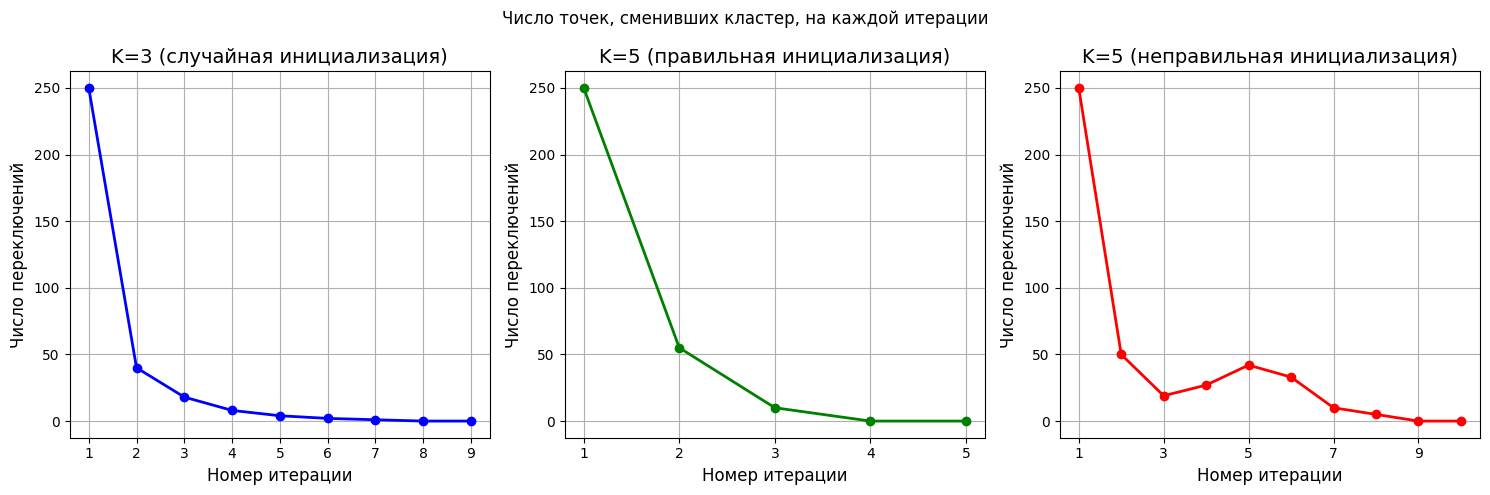

In [309]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(range(1, len(changes_3) + 1), changes_3, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Номер итерации', fontsize=12)
axes[0].set_ylabel('Число переключений', fontsize=12)
axes[0].set_title('K=3 (случайная инициализация)', fontsize=14)
axes[0].grid(True)
axes[0].set_xticks(range(1, len(changes_3) + 1, max(1, len(changes_3)//5)))

axes[1].plot(range(1, len(changes_5_good) + 1), changes_5_good, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('Номер итерации', fontsize=12)
axes[1].set_ylabel('Число переключений', fontsize=12)
axes[1].set_title('K=5 (правильная инициализация)', fontsize=14)
axes[1].grid(True)
axes[1].set_xticks(range(1, len(changes_5_good) + 1, max(1, len(changes_5_good)//5)))

axes[2].plot(range(1, len(changes_5_bad) + 1), changes_5_bad, 'ro-', linewidth=2, markersize=6)
axes[2].set_xlabel('Номер итерации', fontsize=12)
axes[2].set_ylabel('Число переключений', fontsize=12)
axes[2].set_title('K=5 (неправильная инициализация)', fontsize=14)
axes[2].grid(True)
axes[2].set_xticks(range(1, len(changes_5_bad) + 1, max(1, len(changes_5_bad)//5)))

plt.suptitle('Число точек, сменивших кластер, на каждой итерации')
plt.tight_layout()
plt.show()

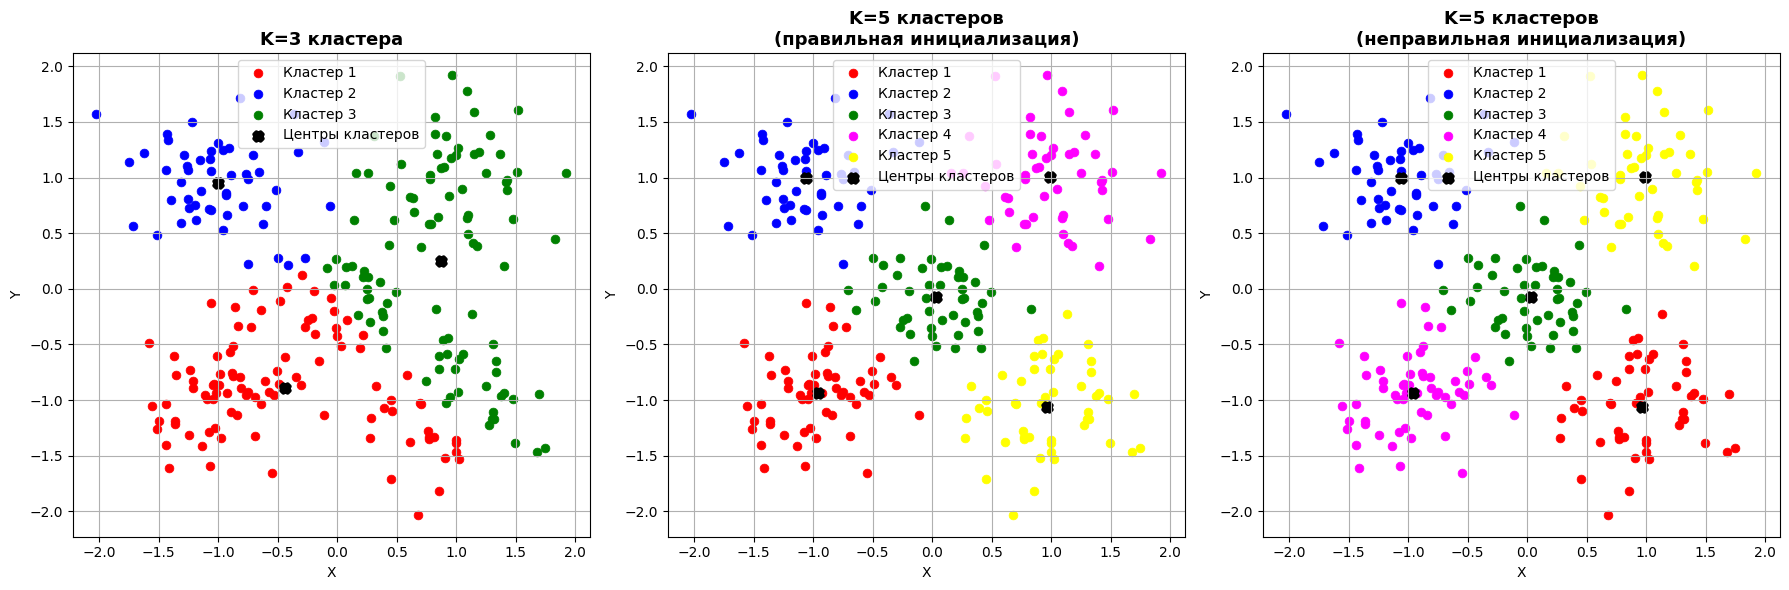

In [310]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cases_clusters = [
    (labels_3, centers_3, "K=3 кластера", axes[0]),
    (labels_5_good, centers_5_good, "K=5 кластеров\n(правильная инициализация)", axes[1]),
    (labels_5_bad, centers_5_bad, "K=5 кластеров\n(неправильная инициализация)", axes[2])
]

cluster_colors = ['red', 'blue', 'green', 'magenta', 'yellow']

for labels, centers, title, ax in cases_clusters:
    k = len(centers)

    for i in range(k):
        mask = (labels == i)
        ax.scatter(X[mask, 0], X[mask, 1], color=cluster_colors[i % len(cluster_colors)], s=40, linewidth=0.5,label=f'Кластер {i+1}')

    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', linewidth=3, label='Центры кластеров')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper center')
    ax.grid(True)

plt.tight_layout()
plt.show()